The objective of this task is to detect hate speech in tweets.
A tweet contains hate speech if it has a racist or sexist sentiment associated with it. So, the task is to classify racist or sexist tweets from other tweets.
Sentiment analysis is also known as opinion mining, where the application of Natural Language Processing. 

https://courses.analyticsvidhya.com/courses/take/twitter-sentiment-analysis/texts/6122229-overview-of-the-course

https://courses.analyticsvidhya.com/courses/take/twitter-sentiment-analysis/texts/6122377-bag-of-words-features

## Load and check the data

In [1]:
import re  # for regular expressions
import nltk # for text manipulation
import string
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train  = pd.read_csv("train_tweets.csv")
test = pd.read_csv("test_tweets.csv")

In [3]:
train

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


label 0 = not racist
label 1 = racist

In [4]:
test

,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."
...,...,...
17192,49155,thought factory: left-right polarisation! #tru...
17193,49156,feeling like a mermaid ð #hairflip #neverre...
17194,49157,#hillary #campaigned today in #ohio((omg)) &am...
17195,49158,"happy, at work conference: right mindset leads..."


Check where label = 1 , racist in train set

In [5]:
train[train['label'] == 1]

,id,label,tweet
13,14,1,@user #cnn calls #michigan middle school 'buil...
14,15,1,no comment! in #australia #opkillingbay #se...
17,18,1,retweet if you agree!
23,24,1,@user @user lumpy says i am a . prove it lumpy.
34,35,1,it's unbelievable that in the 21st century we'...
...,...,...,...
31934,31935,1,lady banned from kentucky mall. @user #jcpenn...
31946,31947,1,@user omfg i'm offended! i'm a mailbox and i'...
31947,31948,1,@user @user you don't have the balls to hashta...
31948,31949,1,"makes you ask yourself, who am i? then am i a..."


In [6]:
# check the dimension of the train, test
train.shape, test.shape

((31962, 3), (17197, 2))

In [7]:
# see how many label counts
train["label"].value_counts()

label
0    29720
1     2242
Name: count, dtype: int64

In [8]:
# check the distribution of the length of the tweets in train and test data
length_train = train['tweet'].str.len()
length_test = test['tweet'].str.len()

length_train, length_test

(0        102
 1        122
 2         21
 3         86
 4         39
         ... 
 31957     68
 31958    131
 31959     63
 31960     67
 31961     32
 Name: tweet, Length: 31962, dtype: int64,
 0         90
 1        101
 2         71
 3        142
 4         93
         ... 
 17192    108
 17193     96
 17194    145
 17195    104
 17196     64
 Name: tweet, Length: 17197, dtype: int64)

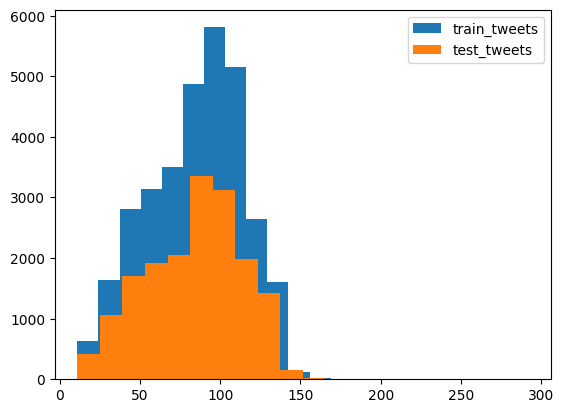

In [9]:
# plot histogram
plt.hist(length_train, bins = 20, label = "train_tweets")
plt.hist(length_test, bins = 20, label = "test_tweets")
plt.legend()
plt.show()

## Data cleaning

In [10]:
combined_data = pd.concat([train, test], ignore_index = True)
combined_data

,id,label,tweet
0,1,0.0,@user when a father is dysfunctional and is s...
1,2,0.0,@user @user thanks for #lyft credit i can't us...
2,3,0.0,bihday your majesty
3,4,0.0,#model i love u take with u all the time in ...
4,5,0.0,factsguide: society now #motivation
...,...,...,...
49154,49155,NaN,thought factory: left-right polarisation! #tru...
49155,49156,NaN,feeling like a mermaid ð #hairflip #neverre...
49156,49157,NaN,#hillary #campaigned today in #ohio((omg)) &am...
49157,49158,NaN,"happy, at work conference: right mindset leads..."


In [11]:
# define a function to remove unwanted text patterns from the tweets 
def remove_pattern(input, pattern):
    result = re.findall(pattern, input)  # finds and returns all matching occurrences in a list

    for i in result: 
        input = re.sub(i, '', input)  # (pattern, replace with, original input)
    return input


In [12]:
# remove username @
combined_data['tidy_tweet'] = np.vectorize(remove_pattern)(combined_data['tweet'], "@[\w]*")  

# \w matches a single word character.
# *: Matches 0 or more occurrences

<>:2: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<>:2: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17708\192485979.py:2: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
  combined_data['tidy_tweet'] = np.vectorize(remove_pattern)(combined_data['tweet'], "@[\w]*")


In [13]:
combined_data

,id,label,tweet,tidy_tweet
0,1,0.0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,2,0.0,@user @user thanks for #lyft credit i can't us...,thanks for #lyft credit i can't use cause th...
2,3,0.0,bihday your majesty,bihday your majesty
3,4,0.0,#model i love u take with u all the time in ...,#model i love u take with u all the time in ...
4,5,0.0,factsguide: society now #motivation,factsguide: society now #motivation
...,...,...,...,...
49154,49155,NaN,thought factory: left-right polarisation! #tru...,thought factory: left-right polarisation! #tru...
49155,49156,NaN,feeling like a mermaid ð #hairflip #neverre...,feeling like a mermaid ð #hairflip #neverre...
49156,49157,NaN,#hillary #campaigned today in #ohio((omg)) &am...,#hillary #campaigned today in #ohio((omg)) &am...
49157,49158,NaN,"happy, at work conference: right mindset leads...","happy, at work conference: right mindset leads..."


In [14]:
# puntuations, numbers, special characters
combined_data['tidy_tweet'] = combined_data['tidy_tweet'].replace("[^a-zA-Z#]", " ", regex=True) 

# need to add regex = True to work
# ^ replace any character that IS NOT a-z OR A-Z and #

In [15]:
combined_data

,id,label,tweet,tidy_tweet
0,1,0.0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,2,0.0,@user @user thanks for #lyft credit i can't us...,thanks for #lyft credit i can t use cause th...
2,3,0.0,bihday your majesty,bihday your majesty
3,4,0.0,#model i love u take with u all the time in ...,#model i love u take with u all the time in ...
4,5,0.0,factsguide: society now #motivation,factsguide society now #motivation
...,...,...,...,...
49154,49155,NaN,thought factory: left-right polarisation! #tru...,thought factory left right polarisation #tru...
49155,49156,NaN,feeling like a mermaid ð #hairflip #neverre...,feeling like a mermaid #hairflip #neverre...
49156,49157,NaN,#hillary #campaigned today in #ohio((omg)) &am...,#hillary #campaigned today in #ohio omg am...
49157,49158,NaN,"happy, at work conference: right mindset leads...",happy at work conference right mindset leads...


In [16]:
#  remove short words like omg, hmm (no use)
combined_data['tidy_tweet'] = combined_data['tidy_tweet'].apply(lambda x: ' '.join(words for words in x.split() 
                                                                                   if len(words) > 3))
# Join all items in a tuple into a string, using a ' ' space character as separator

In [17]:
combined_data

,id,label,tweet,tidy_tweet
0,1,0.0,@user when a father is dysfunctional and is s...,when father dysfunctional selfish drags kids i...
1,2,0.0,@user @user thanks for #lyft credit i can't us...,thanks #lyft credit cause they offer wheelchai...
2,3,0.0,bihday your majesty,bihday your majesty
3,4,0.0,#model i love u take with u all the time in ...,#model love take with time
4,5,0.0,factsguide: society now #motivation,factsguide society #motivation
...,...,...,...,...
49154,49155,NaN,thought factory: left-right polarisation! #tru...,thought factory left right polarisation #trump...
49155,49156,NaN,feeling like a mermaid ð #hairflip #neverre...,feeling like mermaid #hairflip #neverready #fo...
49156,49157,NaN,#hillary #campaigned today in #ohio((omg)) &am...,#hillary #campaigned today #ohio used words li...
49157,49158,NaN,"happy, at work conference: right mindset leads...",happy work conference right mindset leads cult...


In [18]:
# tokenize the tweets (split the string of text into tokens)

tokenized_tweet = combined_data['tidy_tweet'].apply(lambda x: x.split()) # tokenizing

#  nltk.word_tokenize(sentence)  -  alternative

In [19]:
tokenized_tweet

0        [when, father, dysfunctional, selfish, drags, ...
1        [thanks, #lyft, credit, cause, they, offer, wh...
2                                  [bihday, your, majesty]
3                         [#model, love, take, with, time]
4                       [factsguide, society, #motivation]
                               ...                        
49154    [thought, factory, left, right, polarisation, ...
49155    [feeling, like, mermaid, #hairflip, #neverread...
49156    [#hillary, #campaigned, today, #ohio, used, wo...
49157    [happy, work, conference, right, mindset, lead...
49158    [song, glad, free, download, #shoegaze, #newmu...
Name: tidy_tweet, Length: 49159, dtype: object

In [20]:
# normalize the tokenized tweet using nltk

from nltk.stem.porter import *   # A word stemmer based on the Porter stemming algorithm. Stemmers remove morphological affixes from words, leaving only the word stem.

stemmer = PorterStemmer()
tokenized_tweet = tokenized_tweet.apply(lambda x: [stemmer.stem(i) for i in x]) # do the stemming

In [21]:
tokenized_tweet # the words are stemmed

0        [when, father, dysfunct, selfish, drag, kid, i...
1        [thank, #lyft, credit, caus, they, offer, whee...
2                                  [bihday, your, majesti]
3                         [#model, love, take, with, time]
4                             [factsguid, societi, #motiv]
                               ...                        
49154    [thought, factori, left, right, polaris, #trum...
49155    [feel, like, mermaid, #hairflip, #neverreadi, ...
49156    [#hillari, #campaign, today, #ohio, use, word,...
49157    [happi, work, confer, right, mindset, lead, cu...
49158    [song, glad, free, download, #shoegaz, #newmus...
Name: tidy_tweet, Length: 49159, dtype: object

In [22]:
# combined back the tokens, using detokenizer

for i in range (len(tokenized_tweet)):
    tokenized_tweet[i] = ' '.join(tokenized_tweet[i])
combined_data['tidy_tweet'] = tokenized_tweet

In [23]:
combined_data

,id,label,tweet,tidy_tweet
0,1,0.0,@user when a father is dysfunctional and is s...,when father dysfunct selfish drag kid into dys...
1,2,0.0,@user @user thanks for #lyft credit i can't us...,thank #lyft credit caus they offer wheelchair ...
2,3,0.0,bihday your majesty,bihday your majesti
3,4,0.0,#model i love u take with u all the time in ...,#model love take with time
4,5,0.0,factsguide: society now #motivation,factsguid societi #motiv
...,...,...,...,...
49154,49155,NaN,thought factory: left-right polarisation! #tru...,thought factori left right polaris #trump #use...
49155,49156,NaN,feeling like a mermaid ð #hairflip #neverre...,feel like mermaid #hairflip #neverreadi #forma...
49156,49157,NaN,#hillary #campaigned today in #ohio((omg)) &am...,#hillari #campaign today #ohio use word like a...
49157,49158,NaN,"happy, at work conference: right mindset leads...",happi work confer right mindset lead cultur de...


## Data visualization

In [24]:
# visualize the frequency of the word using wordcloud
from wordcloud import WordCloud

word_freq = ' '.join([text for text in combined_data['tidy_tweet']]) 

wordcloud = WordCloud(width = 500, height = 500,
                        random_state = 21,
                        max_font_size = 110).generate(word_freq)


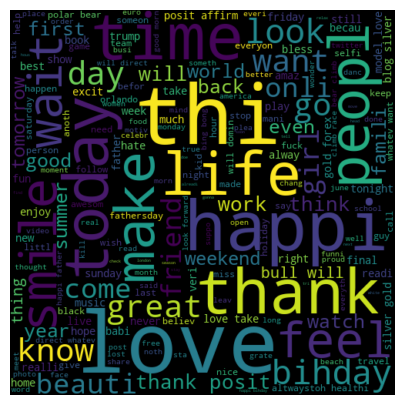

In [25]:
plt.figure(figsize = (5, 5))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis('off')
plt.show()

# most of the words are neutral or positive

In [26]:
# Find the words in non-racist tweets (0)

non_racist = ' '.join([text for text in combined_data['tidy_tweet'][combined_data['label'] == 0]])


In [27]:
non_racist

'when father dysfunct selfish drag kid into dysfunct #run thank #lyft credit caus they offer wheelchair van #disapoint #getthank bihday your majesti #model love take with time factsguid societi #motiv huge fare talk befor they leav chao disput when they there #allshowandnogo camp tomorrow danni next school year year exam think about that #school #exam #hate #imagin #actorslif #revolutionschool #girl love land #allin #cav #champion #cleveland #clevelandcavali welcom here #ireland consum price index climb from previou #blog #silver #gold #forex selfish #orlando #standwithorlando #pulseshoot #orlandoshoot #biggerproblem #selfish #heabreak #valu #love daddi today day #gettingf ouch junior angri #got #junior #yugyoem #omg thank have paner #thank #posit #friday smile around user #cooki make peopl know essenti oil made chemic #euro peopl blame conced goal rooney gave away free kick know bale them from there littl dude #badday #coneofsham #cat #piss #funni #laugh product happi #wine tool #week

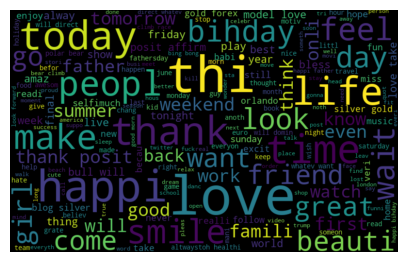

In [28]:
wordcloud = WordCloud(width = 800, height = 500, random_state = 21, max_font_size = 110).generate(non_racist)
plt.figure(figsize = (5, 5))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis('off')
plt.show()

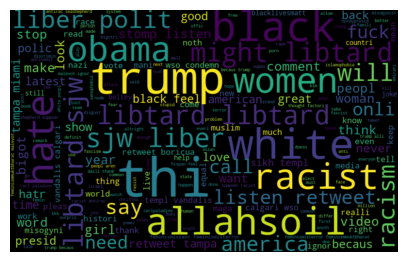

In [29]:
# Find the words in racist tweets (0)

racist = ' '.join([text for text in combined_data['tidy_tweet'][combined_data['label'] == 1]])

wordcloud = WordCloud(width = 800, height = 500, random_state = 21, max_font_size = 110).generate(racist)
plt.figure(figsize = (5, 5))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis('off')
plt.show()

In [30]:
# check the hashtag

# function to collect hastag
def hashtag_extract(x):
    hashtags = [] 

    # loop over the words in the tweet 
    for i in x:
        ht = re.findall(r"#(\w+)", i) # r-raw string
        hashtags.append(ht)
    return hashtags


In [31]:
combined_data['tidy_tweet'][combined_data['label'] == 1]

13       #cnn call #michigan middl school build wall ch...
14       comment #australia #opkillingbay #seashepherd ...
17                                            retweet agre
23                                   lumpi say prove lumpi
34       unbeliev that centuri need someth like thi aga...
                               ...                        
31934       ladi ban from kentucki mall #jcpenni #kentucki
31946    omfg offend mailbox proud #mailboxprid #libera...
31947     have ball hashtag weasel away lumpi toni dipshit
31948               make yourself then anybodi until thank
31960          #sikh #templ vandalis #calgari #wso condemn
Name: tidy_tweet, Length: 2242, dtype: object

In [32]:
# extract the hashtags from non-racist / sexist tags
HT_regular = hashtag_extract(combined_data['tidy_tweet'][combined_data['label'] == 0])

# extract racist hashtags
HT_negative = hashtag_extract(combined_data['tidy_tweet'][combined_data['label'] == 1])


In [33]:
HT_regular

[['run'],
 ['lyft', 'disapoint', 'getthank'],
 [],
 ['model'],
 ['motiv'],
 ['allshowandnogo'],
 [],
 ['school', 'exam', 'hate', 'imagin', 'actorslif', 'revolutionschool', 'girl'],
 ['allin', 'cav', 'champion', 'cleveland', 'clevelandcavali'],
 [],
 ['ireland', 'blog', 'silver', 'gold', 'forex'],
 ['orlando',
  'standwithorlando',
  'pulseshoot',
  'orlandoshoot',
  'biggerproblem',
  'selfish',
  'heabreak',
  'valu',
  'love'],
 ['gettingf'],
 ['got', 'junior', 'yugyoem', 'omg'],
 ['thank', 'posit'],
 ['friday', 'cooki'],
 [],
 ['euro'],
 ['badday', 'coneofsham', 'cat', 'piss', 'funni', 'laugh'],
 ['wine', 'weekend'],
 ['tgif', 'gamedev', 'indiedev', 'indiegamedev', 'squad'],
 ['upsideofflorida', 'shopalyssa', 'love'],
 ['smile', 'media', 'pressconfer', 'antalya', 'turkey', 'throwback'],
 ['ica'],
 [],
 ['rip', 'orlando'],
 [],
 ['alohafriday', 'time', 'not', 'exist', 'positivevib', 'hawaiian'],
 [],
 ['goodnight', 'badmonday'],
 ['taylorswift'],
 ['travelingram', 'dalat', 'ripinkyli

In [34]:
# unnest the list
HT_regular = sum(HT_regular, [])  # same as summing [1,2] + [3,4] = [1,2,3,4]
HT_negative = sum(HT_negative, [])

In [35]:
HT_regular

['run',
 'lyft',
 'disapoint',
 'getthank',
 'model',
 'motiv',
 'allshowandnogo',
 'school',
 'exam',
 'hate',
 'imagin',
 'actorslif',
 'revolutionschool',
 'girl',
 'allin',
 'cav',
 'champion',
 'cleveland',
 'clevelandcavali',
 'ireland',
 'blog',
 'silver',
 'gold',
 'forex',
 'orlando',
 'standwithorlando',
 'pulseshoot',
 'orlandoshoot',
 'biggerproblem',
 'selfish',
 'heabreak',
 'valu',
 'love',
 'gettingf',
 'got',
 'junior',
 'yugyoem',
 'omg',
 'thank',
 'posit',
 'friday',
 'cooki',
 'euro',
 'badday',
 'coneofsham',
 'cat',
 'piss',
 'funni',
 'laugh',
 'wine',
 'weekend',
 'tgif',
 'gamedev',
 'indiedev',
 'indiegamedev',
 'squad',
 'upsideofflorida',
 'shopalyssa',
 'love',
 'smile',
 'media',
 'pressconfer',
 'antalya',
 'turkey',
 'throwback',
 'ica',
 'rip',
 'orlando',
 'alohafriday',
 'time',
 'not',
 'exist',
 'positivevib',
 'hawaiian',
 'goodnight',
 'badmonday',
 'taylorswift',
 'travelingram',
 'dalat',
 'ripinkylif',
 'photoshop',
 'enoughisenough',
 'dontph

In [36]:
HT_negative


['cnn',
 'michigan',
 'tcot',
 'australia',
 'opkillingbay',
 'seashepherd',
 'helpcovedolphin',
 'thecov',
 'helpcovedolphin',
 'neverump',
 'xenophobia',
 'love',
 'peac',
 'race',
 'ident',
 'med',
 'altright',
 'whitesupremaci',
 'linguist',
 'race',
 'power',
 'raciolinguist',
 'brexit',
 'peopl',
 'trump',
 'republican',
 'michelleobama',
 'knick',
 'golf',
 'jewishsupremacist',
 'libtard',
 'sjw',
 'liber',
 'polit',
 'trash',
 'hate',
 'stereotyp',
 'prejudic',
 'hope',
 'hate',
 'conflict',
 'pol',
 'bluelivesmatt',
 'draintheswamp',
 'ferguson',
 'antisemit',
 'hocoschool',
 'columbiamd',
 'hocomd',
 'nazi',
 'hatr',
 'bigotri',
 'libtard',
 'sjw',
 'liber',
 'polit',
 'fyi',
 'tcot',
 'topoli',
 'blacklivesmatt',
 'ushistori',
 'eugen',
 'biher',
 'bigotri',
 'altright',
 'potu',
 'theresist',
 'crime',
 'offic',
 'black',
 'retweet',
 'tampa',
 'miami',
 'allahsoil',
 'prais',
 'cleveland',
 'rnc',
 'white',
 'tamirric',
 'rip',
 'bigot',
 'blacklivesmatt',
 'feminismiscanc

In [37]:
# plot the top n hashtags
freq = nltk.FreqDist(HT_regular)


In [38]:
freq_df = pd.DataFrame({'Hashtag': list(freq.keys()), 
                  'Count': list(freq.values())})

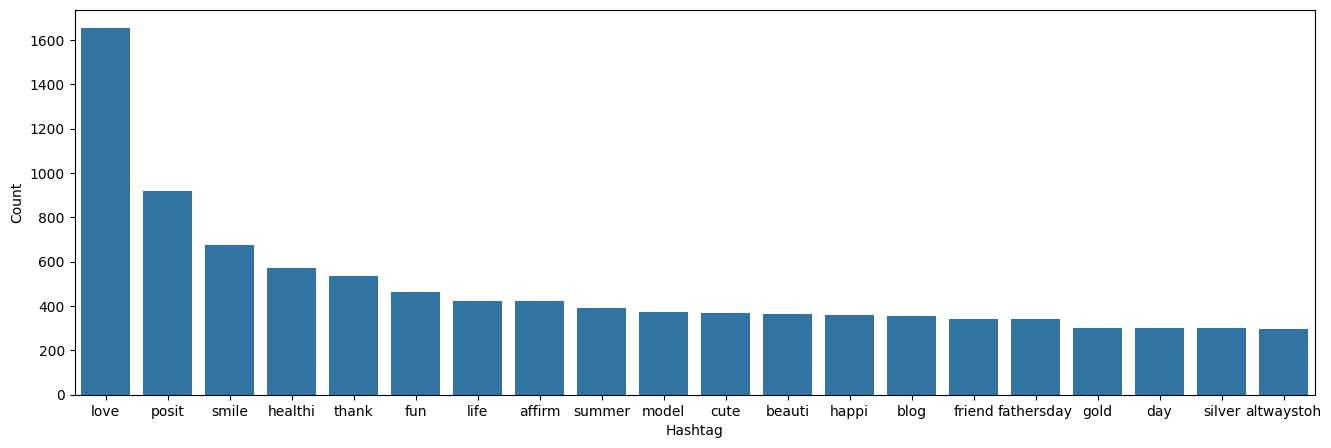

In [39]:
# select the top 20 most frequent hashtags
freq_df = freq_df.nlargest(columns = 'Count', n=20)
plt.figure(figsize = (16,5))
ax = sns.barplot(data = freq_df, 
                 x = "Hashtag", 
                 y = 'Count')
ax.set(ylabel = 'Count')
plt.show()

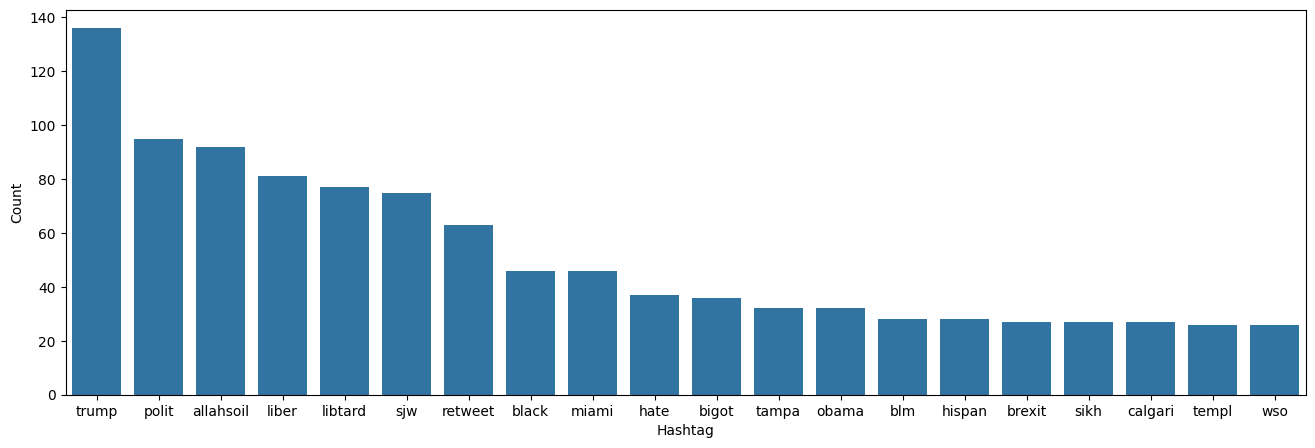

In [40]:
# plot the top n hashtags
freq_nev = nltk.FreqDist(HT_negative)

freq_df_nev = pd.DataFrame({'Hashtag': list(freq_nev.keys()), 
                  'Count': list(freq_nev.values())})

# select the top 20 most frequent hashtags
freq_df_nev = freq_df_nev.nlargest(columns = 'Count', n=20)
plt.figure(figsize = (16,5))
ax2 = sns.barplot(data = freq_df_nev, 
                 x = "Hashtag", 
                 y = 'Count')
ax2.set(ylabel = 'Count')
plt.show()

## Converting into features

In [41]:
# https://courses.analyticsvidhya.com/courses/take/twitter-sentiment-analysis/texts/6122377-bag-of-words-features

### Bag-of-words features

Machine learning algorithms cannot work with raw text directly; the text must be converted into numbers. Specifically, vectors of numbers. This is called feature extraction or feature encoding.

A bag-of-words is a representation of text that describes the occurrence of words within a document. It involves two things:
    A vocabulary of known words.
    A measure of the presence of known words.
a “bag” of words, because any information about the order or structure of words in the document is discarded

The objective is to turn each document of free text into a vector that we can use as input or output for a machine learning model.
The simplest scoring method is to mark the presence of words as a boolean value, 0 for absent, 1 for present.

CountVectorizer tokenizes the text, removes punctuation, and lowercase the words automatically

.fit_transform(corpus) converts the corpus into a document-term matrix, where each row represents a document and each column represents a word from the vocabulary.



In [42]:
from sklearn.feature_extraction.text import CountVectorizer
bow_vectorizer = CountVectorizer(max_df = 0.90,
                                 min_df = 2,
                                 max_features = 1000,
                                 stop_words = 'english')
bow = bow_vectorizer.fit_transform(combined_data['tidy_tweet'])



In [43]:
bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 191502 stored elements and shape (49159, 1000)>

In [44]:
bow.shape

(49159, 1000)

### TF-IDF feature 

Term Frequency – Inverse Document Frequency, or TF-IDF for short

 to rescale the frequency of words by how often they appear in all documents, so that the scores for frequent words like “the” that are also frequent across all documents are penalized.

Term Frequency: is a scoring of the frequency of the word in the current document.
Inverse Document Frequency: is a scoring of how rare the word is across documents.



In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_df = 0.90, 
                                  min_df = 2,
                                  max_features = 1000,
                                  stop_words = 'english')

tfidf = tfidf_vectorizer.fit_transform(combined_data['tidy_tweet'])


Consider a document containing 200 words, where the word love appears 5 times. The TF for love is then (5 / 200) = 0.025. Assuming we had one million documents and the word love occurs in one thousand of these, the inverse document frequency (i.e., IDF) is calculated as log(1000000 / 1000) = 3. The TF-IDF weight is the product of these quantities: 0.025 * 3 = 0.075.

The TF-IDF matrix implemented above gives you a weighted measure instead of raw frequencies.

In [46]:
tfidf.shape

(49159, 1000)

In [47]:
# pip install --use-pep517 gensim==3.8.0

### Word2Vec 

In [48]:
# from gensim.models import Word2Vec

# tokenized_tweet = combined_data['tidy_tweet'].apply(lambda x: x.split())  # tokenizing

# model_w2v = genism.models.Word2Vec(tokenized_tweet, 
#                                    size = 200, # desired number of features / independent variables
#                                    window = 5, # context window size
#                                    min_count = 2,
#                                    sg = 1, # 1 for skip gram model
#                                    hs = 0,
#                                    negative = 10, # for negative sampling
#                                    workers = 2, # number of cores
#                                    seed = 34)

In [49]:
# model_w2v.train(tokenized_tweet, 
#                 total_examples = len(combined_data['tidy_tweet']),
#                 epochs = 20)

In [50]:
# model_w2v.wv.most_similar(positive = "dinner")

In [51]:
# model_w2v.wv.most_similar(positive = "trump")

In [52]:
# model_w2v['food']

In [53]:
# len(model_w2v['food]) # the length of the vector is 200

## Modelling

### Logistic regression

In [54]:
# Logistic regression
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score


Logistic regression is a classification algorithm ,and predict a 1 or 0 outcome. 

In [ ]:
# first fit the logistic regression model on the Bag-of-words features

# Extracting train and test BoW features 
train_bow = bow[:31962, :]  # about 65%
test_bow = bow[31962:, :]

# splitting data into training and validation set
xtrain_bow, xvalid_bow, ytrain, yvalid = train_test_split(train_bow, train['label'],
                                                          random_state = 42, 
                                                          test_size = 0.3)



In [56]:
logis_reg = LogisticRegression()

# train the model 
logis_reg.fit(xtrain_bow, ytrain)
prediction = logis_reg.predict_proba(xvalid_bow) # predicting on validation set 
prediction_int = prediction[:, 1] >= 0.3 # if prediction is greater than or equal to 0.3 than 1, else 0
prediction_int = prediction_int.astype(int)



F1 score takes in both false positive and false negative  into account. It is suitable for uneven class distribution problems.

In [57]:
f1_score(yvalid, prediction_int) # calculating f1 score for the validation set

0.5307820299500832

In [58]:
# now make predictions for the test dataset and create a submission file
test_pred = logis_reg.predict_proba(test_bow)
test_pred_int = test_pred[:,1] >= 0.3
test_pred_int = test_pred_int.astype(int)
test['label'] = test_pred_int




In [59]:
submission = test[['id', 'label']]

In [60]:
submission.to_csv('sub_logis_reg_bow.csv', index = False) # write file to csv

In [61]:
# f1_score(yvalid, prediction_int)  # public leaderboard F1 score: 0.567

In [62]:
# now train with the TF-IDF feature set
train_tfidf = tfidf[:31962, :] 
test_tfidf = tfidf[31962:, :]

xtrain_tfidf = train_tfidf[ytrain.index]
xvalid_tfidf = train_tfidf[yvalid.index]


In [63]:
logis_reg.fit(xtrain_tfidf, ytrain)
prediction = logis_reg.predict_proba(xvalid_tfidf)
prediction_int = prediction[:, 1] > 0.3
prediction_int = prediction_int.astype(int)
f1_score(yvalid, prediction_int) # calculate f1 score for the validation set
 

0.5475352112676056

### SVM

SVM perform classification by finding the hyperplane that differentiate the two classes

In [64]:
# svm mostly used in classification problem
from sklearn import svm

In [65]:
# bags of words features
svc = svm.SVC(kernel = 'linear',
              C = 1, 
              probability = True)
svc.fit(xtrain_bow, ytrain)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [66]:
prediction = svc.predict_proba(xvalid_bow)
prediction_int = prediction[:,1] >= 0.3
prediction_int = prediction_int.astype(int)
f1_score(yvalid, prediction_int)

0.5074626865671642

In [67]:
# create prediction for the test data set and create another submission file

test_pred = svc.predict_proba(test_bow)
test_pred_int = test_pred[:,1] >= 0.3
test_pred_int = test_pred_int.astype(int)
test['label'] = test_pred_int
submission = test[['id', 'label']]
submission.to_csv('sub_svm_bow.csv', index = False)

# public leaderboard f1 score: 0.554

In [68]:
# TF-IDF features
svc = svm.SVC(kernel = 'linear',
              C = 1, 
              probability = True)
svc.fit(xtrain_tfidf, ytrain)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [69]:
prediction = svc.predict_proba(xvalid_tfidf)
prediction_int = prediction[:,1] >= 0.3
prediction_int = prediction_int.astype(int)
f1_score(yvalid, prediction_int)

# public leaderboard F1 score = 0.546

0.5109489051094891

### Random Forest

In [70]:
from sklearn.ensemble import RandomForestClassifier

In [71]:
# Bag-of-words

rf = RandomForestClassifier(n_estimators = 400, 
                            random_state = 11)

rf.fit(xtrain_bow, ytrain)
prediction = rf.predict(xvalid_bow)

# validation score
f1_score(yvalid, prediction)

0.5506329113924051

In [72]:
# make prediction for the test dataset, and make another submission file

test_pred = rf.predict(test_bow)
test['label'] = test_pred
submission = test[['id', 'label']]
submission.to_csv('sub_rf_bow.csv', index = False)

In [73]:
# TFIDF Features
rf = RandomForestClassifier(n_estimators = 400,
                            random_state = 11)

rf.fit(xtrain_tfidf, ytrain)
prediction = rf.predict(xvalid_tfidf)
f1_score(yvalid, prediction)

0.5571955719557196

### XGboost

Extreme gradient boosting algorithm
- both a linear model solver and tree learning algorithm

XGBoost develops one tree at a time, correcting faults caused by previously trained trees, in contrast to Random Forest, where each tree is generated independently and the results are aggregated at the end

The model uses a gradient descent algorithm to minimize the loss when adding new models. This sequential addition of weak learners (trees) ensures that the shortcomings of previous trees are corrected. 

XGBoost is optimized for speed and performance. It is designed to be highly efficient and can handle large-scale data better than Random Forest

In [75]:
from xgboost import XGBClassifier

In [76]:
xgb_model = XGBClassifier(max_depth = 6, 
                          n_estimators = 1000)

xgb_model.fit(xtrain_bow, ytrain)
prediction = xgb_model.predict(xvalid_bow)
f1_score(yvalid, prediction)

0.5288197621225984

In [78]:
test_pred = xgb_model.predict(test_bow)
test['label'] = test_pred
submission = test[['id', 'label']]
submission.to_csv('sub_xgb_bow.csv', index = False)

In [79]:
# TFIDF features
xgb = XGBClassifier(max_depth = 6, 
                    n_estimators = 1000)

xgb.fit(xtrain_tfidf, ytrain)
prediction = xgb.predict(xvalid_tfidf)
f1_score(yvalid, prediction)

0.5461056401074306

Next we may also try grid search method. 